In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import SBVGPResult2, SIResult, FlowPriorResult
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl

import torch
import matplotlib.pyplot as plt
import seaborn as sns


torch.manual_seed(42)

[2024-08-23 13:52:07,415][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-08-23 13:52:07,630][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
restriction = "dl_id = 'f7b32dd97feda9f34e2b47e24fa3d18b'"
best_si = (SIResult & restriction).fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]
best_sbv = (SBVGPResult2 & restriction).fetch(
    download_path="/tmp", order_by="val_ll_mean DESC", limit=1, as_dict=True
)[0]

best_si_model = torch.load(best_si["model"], map_location="cpu")
best_sbv_model = torch.load(best_sbv["model"], map_location="cpu")

In [3]:
best_si_model

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=1, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
          (linear_1): Linear(in_features=1, out_features=1, bias=True)
          (dropout_1): Dropout(p=0.0, inplace=False)
          (nonlin_1): ReLU()
        )
      )
      (conc_module): Linear(in_features=1, out_features=1, bias=True)
      (rate_module): Linear(in_features=1, out_features=1, bias=True)
    )
  )
)

In [4]:
best_sbv_model

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=1, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
          (linear_1): Linear(in_features=1, out_features=1, bias=True)
          (dropout_1): Dropout(p=0.0, inplace=False)
          (nonlin_1): ReLU()
        )
      )
      (conc_module): Linear(in_features=1, out_features=1, bias=True)
      (rate_module): Linear(in_features=1, out_features=1, bias=True)
    )
  )
)

In [5]:
dataloader_config = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader, val_loader, test_loader = build_dataloaders(
    data_fname=dataloader_config["data_fname"],
    train_prop=dataloader_config["train_prop"],
    val_prop=dataloader_config["val_prop"],
    batch_size=dataloader_config["batch_size"],
)

In [34]:
# orientations = torch.tensor([0.0])
orientations = torch.linspace(0, torch.pi, steps=45 + 1)[:-1][::11]
obs_h, obs_w = 12, 12
gabor_params = dict(
    {
        "canvas_size": [obs_h, obs_w],
        "sizes": [10],
        "spatial_frequencies": [1 / 3],
        "contrasts": [1.0],
        "grey_levels": [0.0],
        "eccentricities": [0.0],
        "locations": [[6, 6]],
        "phases": [torch.pi / 2],
        "relative_sf": False,
    },
)
stimuli = torch.Tensor(
    generate_gabors(orientations=orientations.tolist(), gabor_params=gabor_params)
)

In [35]:
stimuli.shape

torch.Size([5, 12, 12])

In [13]:
best_si_model

IndependentGamma(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.gamma.Gamma'>, event_dims=1
    (parameter_generator): ConcRate(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=144, out_features=1, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): ReLU()
          (linear_1): Linear(in_features=1, out_features=1, bias=True)
          (dropout_1): Dropout(p=0.0, inplace=False)
          (nonlin_1): ReLU()
        )
      )
      (conc_module): Linear(in_features=1, out_features=1, bias=True)
      (rate_module): Linear(in_features=1, out_features=1, bias=True)
    )
  )
)

In [36]:
stimuli.shape

torch.Size([5, 12, 12])

In [39]:
best_si_model.eval()
best_sbv_model.eval()
si_pdfs = []
sbv_pdfs = []
zero = torch.finfo(torch.float32).eps
x = torch.linspace(zero, 6, steps=1000).unsqueeze(-1)
for stimulus in stimuli:
    with torch.no_grad():
        si_dist = best_si_model.trainable_distribution.distribution(cond=stimulus.reshape(-1, obs_h * obs_w))
        si_pdfs.append(si_dist.log_prob(x).exp())
        sbv_dist = best_sbv_model.trainable_distribution.distribution(cond=stimulus.reshape(-1, obs_h * obs_w))
        sbv_pdfs.append(sbv_dist.log_prob(x).exp())

In [42]:
si_pdfs = torch.stack(si_pdfs)

In [43]:
sbv_pdfs = torch.stack(sbv_pdfs)

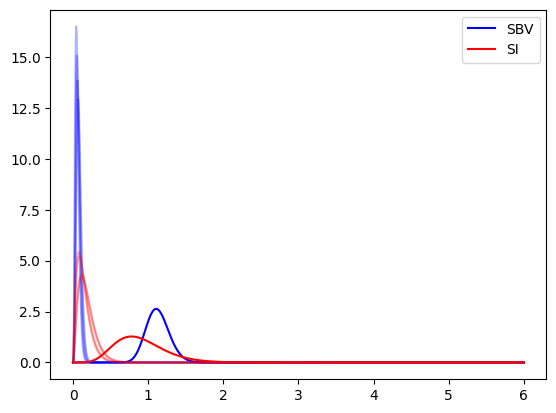

In [56]:
plt.plot(x.flatten(), sbv_pdfs[0].T, label="SBV", color="blue")
plt.plot(x.flatten(), sbv_pdfs[1:].T, color="blue", alpha=0.3)
plt.plot(x.flatten(), si_pdfs[0].T, label="SI", color="red")
plt.plot(x.flatten(), si_pdfs[1:].T, color="red", alpha=0.3)
plt.legend()